# 📊 Visualization Results

Đọc kết quả từ CSV và vẽ biểu đồ.

✓ Loaded: correctness_results.csv
✓ Loaded: time_fi_results.csv
✓ Loaded: memory_results.csv
✓ Loaded: scalability_results.csv
✓ Loaded: txlen_results.csv

=== CORRECTNESS RESULTS ===


,Dataset,Minsup_Pct,Minsup_Count,Num_FI_Our,Num_FI_SPMF,Matched,Match_Rate_Pct,Analysis
0,Chess,85.0,2717,2669,2669,2669,100.0,MATCH
1,Chess,80.0,2557,8227,8227,8227,100.0,MATCH
2,Chess,75.0,2397,20993,20993,20993,100.0,MATCH
3,Mushroom,30.0,2438,2735,2735,2735,100.0,MATCH
4,Mushroom,25.0,2031,5545,5545,5545,100.0,MATCH
5,Mushroom,20.0,1625,53583,53583,53583,100.0,MATCH
6,Retail,5.0,4409,16,16,16,100.0,MATCH
7,Retail,3.0,2645,32,32,32,100.0,MATCH
8,Retail,2.0,1764,55,55,55,100.0,MATCH
9,Accidents,90.0,306165,31,31,31,100.0,MATCH



=== TIME & FI RESULTS ===


,Dataset,Minsup_Pct,Time_Basic_ms,Time_Opt_ms,Time_SPMF_ms,Num_FI
0,Chess,90.0,29.25,27.49,617.70,622
1,Chess,85.0,139.88,104.49,568.25,2669
2,Chess,80.0,565.67,254.34,555.60,8227
3,Chess,75.0,1354.41,569.88,629.62,20993
4,Chess,70.0,2155.69,1326.07,594.70,48731
5,Chess,65.0,9732.16,3268.05,631.18,111239
6,Mushroom,40.0,84.88,51.66,622.50,565
7,Mushroom,35.0,91.74,115.44,619.95,1189
8,Mushroom,30.0,289.97,271.17,583.46,2735
9,Mushroom,25.0,424.33,352.22,652.42,5545


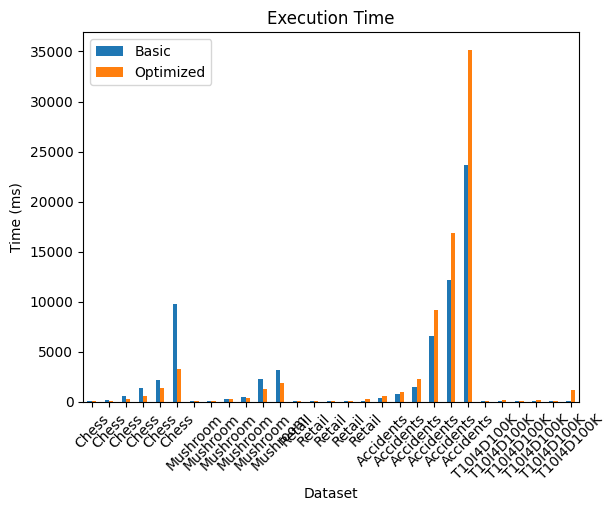


=== MEMORY RESULTS ===


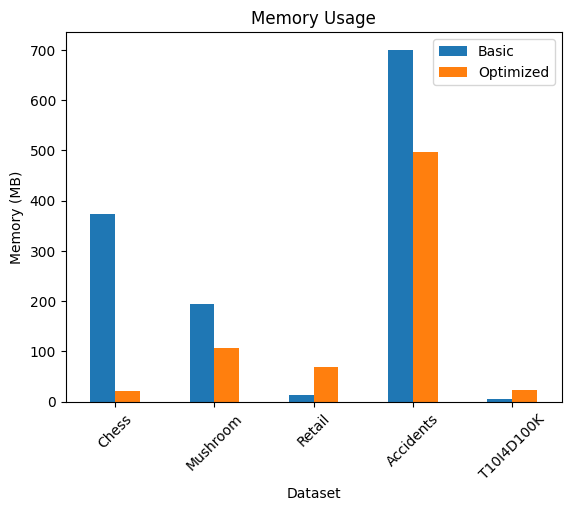


=== SCALABILITY RESULTS ===


,Subset_Pct,Num_Trans,Minsup_Count,Time_Basic_ms,Time_Opt_ms,Num_FI_Basic,Num_FI_Opt,Trend
0,10,8817,177,7.30,45.71,63,63,Baseline
1,25,22041,441,18.77,81.60,59,59,Linear
2,50,44081,882,40.12,256.23,59,59,Linear
3,75,66122,1323,56.77,266.75,54,54,Linear
4,100,88162,1764,94.16,451.29,55,55,Superlinear


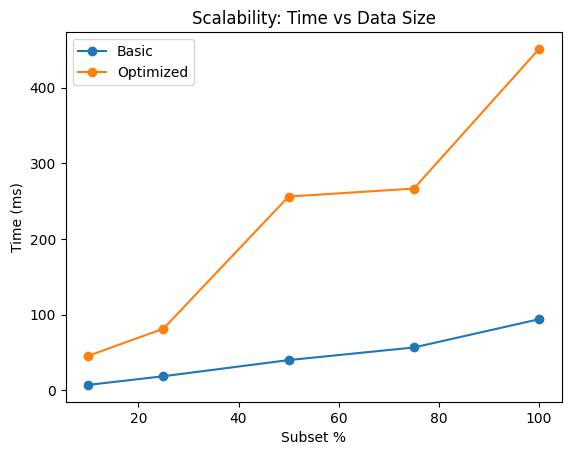


=== TX LENGTH RESULTS ===


,Avg_TxLen,Time_Basic_ms,Time_Opt_ms,Num_FI_Basic,Num_FI_Opt,Analysis
0,3,1.64,2.95,0,0,Low_impact
1,4,1.86,2.04,0,0,Low_impact
2,5,2.23,4.12,0,0,Low_impact
3,6,2.82,3.20,0,0,Medium_impact
4,7,2.94,4.60,0,0,Medium_impact
5,8,3.34,3.95,0,0,Medium_impact
6,9,3.77,3.82,0,0,Medium_impact
7,10,5.23,4.22,0,0,Medium_impact


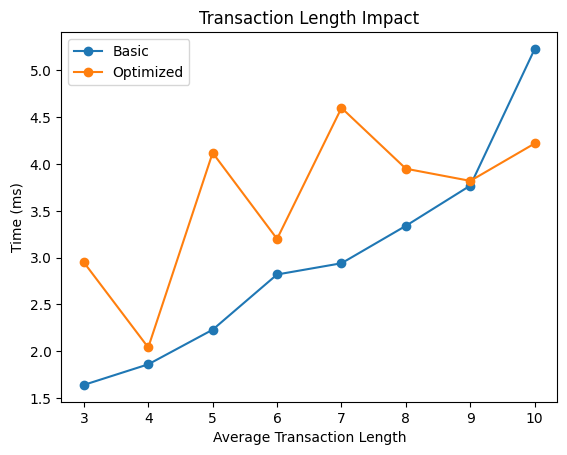

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import os

RESULTS_DIR = os.path.join(os.getcwd(), "..", "data", "results")

csv_files = [
    "correctness_results.csv",
    "time_fi_results.csv",
    "memory_results.csv",
    "scalability_results.csv",
    "txlen_results.csv"
]

dfs = {}

# Load CSV
for file in csv_files:
    path = os.path.join(RESULTS_DIR, file)
    if os.path.isfile(path):
        dfs[file] = pd.read_csv(path)
        print("✓ Loaded:", file)
    else:
        print("⚠ Missing:", file)

# =========================
# Correctness Results
# =========================
if "correctness_results.csv" in dfs:
    df = dfs["correctness_results.csv"]
    print("\n=== CORRECTNESS RESULTS ===")
    display(df)

# =========================
# Time & FI Benchmark
# =========================
if "time_fi_results.csv" in dfs:
    df = dfs["time_fi_results.csv"]
    print("\n=== TIME & FI RESULTS ===")
    display(df)

    df.plot(x="Dataset", y=["Time_Basic_ms", "Time_Opt_ms"], kind="bar", rot=45)
    plt.title("Execution Time")
    plt.ylabel("Time (ms)")
    plt.legend(["Basic", "Optimized"])
    plt.show()

# =========================
# Memory Benchmark
# =========================
if "memory_results.csv" in dfs:
    df = dfs["memory_results.csv"]
    print("\n=== MEMORY RESULTS ===")
    df.plot(
        x="Dataset",
        y=["Mem_Basic_MB", "Mem_Opt_MB"],
        kind="bar",
        rot=45
    )

    plt.title("Memory Usage")
    plt.ylabel("Memory (MB)")
    plt.legend(["Basic", "Optimized"])
    plt.show()

# =========================
# Scalability Results
# =========================
if "scalability_results.csv" in dfs:
    df = dfs["scalability_results.csv"]
    print("\n=== SCALABILITY RESULTS ===")
    display(df)

    plt.plot(df["Subset_Pct"], df["Time_Basic_ms"], marker="o", label="Basic")
    plt.plot(df["Subset_Pct"], df["Time_Opt_ms"], marker="o", label="Optimized")
    plt.title("Scalability: Time vs Data Size")
    plt.xlabel("Subset %")
    plt.ylabel("Time (ms)")
    plt.legend()
    plt.show()

# =========================
# Transaction Length Results
# =========================
if "txlen_results.csv" in dfs:
    df = dfs["txlen_results.csv"]
    print("\n=== TX LENGTH RESULTS ===")
    display(df)

    plt.plot(df["Avg_TxLen"], df["Time_Basic_ms"], marker="o", label="Basic")
    plt.plot(df["Avg_TxLen"], df["Time_Opt_ms"], marker="o", label="Optimized")
    plt.title("Transaction Length Impact")
    plt.xlabel("Average Transaction Length")
    plt.ylabel("Time (ms)")
    plt.legend()
    plt.show()